In [3]:
# %% [markdown]
# # Домашнее задание: Multi-Branch MLP для Wine Quality
#
# **Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%
#
# **Задачи**:
# 1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
# 2. Создать Multi-Branch архитектуру
# 3. Использовать weighted loss для борьбы с дисбалансом классов
# 4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

# %%
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
sys.path.append('../../lesson3/seminar')
from lesson3.seminar.wine_quality_data import WineQualityDataModule
from lesson3.seminar.lightning_module import BaseLightningModule
from lesson3.seminar.utils import set_seed
from pytorch_lightning import Trainer

sns.set_style('whitegrid')
set_seed(42)



# %% [markdown]
# ## 1. Загрузка и анализ данных
#
# Загрузим Wine Quality датасет и проанализируем распределение классов.

# %%
# Загружаем данные

In [4]:
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

# %% [markdown]
# ### 1.1. Анализ дисбаланса классов
#
# Проанализируйте распределение классов и вычислите веса для weighted loss.

# %%
# Получите метки классов из train_dataset



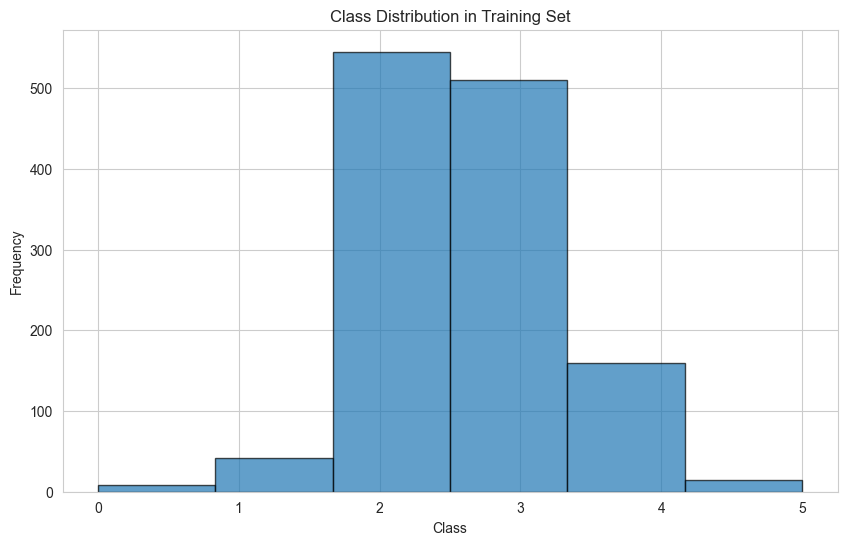

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]


In [5]:
train_labels = []
for i in range(len(dm.train_dataset)):
    _, label = dm.train_dataset[i]
    train_labels.append(label)
train_labels = np.array(train_labels)

# Постройте гистограмму распределения классов
plt.figure(figsize=(10, 6))
plt.hist(train_labels, bins=len(np.unique(train_labels)), alpha=0.7, edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution in Training Set')
plt.show()

# Вычислите веса классов используя compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

print(f'Class weights: {class_weights}')


# %% [markdown]
# ## 2. Реализация блоков
#
# Реализуйте три типа блоков:
# - **Bottleneck**: dim → dim//4 → dim (сужение)
# - **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
# - **Regular**: dim → hidden_dim → dim (обычный)

# %%

In [6]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None

    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim

    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)

        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)

    def forward(self, x):
        identity = x

        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim

    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor

        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)

    def forward(self, x):
        identity = x

        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim

    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2

        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)

    def forward(self, x):
        identity = x

        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


# %% [markdown]
# ## 3. Multi-Branch модель
#
# Реализуйте модель с тремя параллельными ветками.
#
# **Архитектура**:
# ```
#          Input
#            |
#       projection
#            |
#       ┌────┼────┐
#       │    │    │
#   Bottleneck  Inverted  Regular
#    Branch      Branch    Branch
#       │    │    │
#       └────┼────┘
#            |
#       Concatenate/Sum
#            |
#       projection
#            |
#         Output
# ```

# %%

In [7]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.

    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Создайте три ветки (branches)
        # Branch 1: num_blocks блоков BottleneckBlock
        # Branch 2: num_blocks блоков InvertedBottleneckBlock
        # Branch 3: num_blocks блоков RegularBlock
        self.bottleneck_branch = nn.ModuleList([
            BottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])

        self.inverted_branch = nn.ModuleList([
            InvertedBottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])

        self.regular_branch = nn.ModuleList([
            RegularBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])

        # Выходная проекция
        # Если combine_mode == 'concat', то вход будет hidden_dim * 3
        # Если combine_mode == 'sum', то вход будет hidden_dim
        if combine_mode == 'concat':
            output_proj_input = hidden_dim * 3
        else:  # sum
            output_proj_input = hidden_dim

        self.output_proj = nn.Sequential(
            nn.Linear(output_proj_input, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Входная проекция
        x = self.input_proj(x)
        x = self.activation(x)
        x = self.dropout(x)

        # 2. Пропустите через каждую ветку
        bottleneck_out = x
        for block in self.bottleneck_branch:
            bottleneck_out = block(bottleneck_out)

        inverted_out = x
        for block in self.inverted_branch:
            inverted_out = block(inverted_out)

        regular_out = x
        for block in self.regular_branch:
            regular_out = block(regular_out)

        # 3. Объедините результаты (concat или sum)
        if self.combine_mode == 'concat':
            combined = torch.cat([bottleneck_out, inverted_out, regular_out], dim=-1)
        else:  # sum
            combined = bottleneck_out + inverted_out + regular_out

        # 4. Выходная проекция
        output = self.output_proj(combined)

        return output

print('Multi-Branch модель определена!')


Multi-Branch модель определена!


 4. Код обучение

In [8]:

# %%
def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam'
):
    """
    Обучает модель с weighted loss.

    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')

    Returns:
        dict с метриками
    """
    # Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()

    # Создаем временный атрибут output_dim для совместимости с BaseLightningModule
    if not hasattr(model, 'output_dim'):
        # Предполагаем, что последний слой - линейный с output_dim нейронов
        for module in model.modules():
            if isinstance(module, nn.Linear) and module.out_features == dm.n_classes:
                model.output_dim = dm.n_classes
                break
        else:
            # Если не нашли, устанавливаем вручную
            model.output_dim = dm.n_classes

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }


5. Подбор гиперпараметров


In [9]:
# %%
# Поиск лучших гиперпараметров
best_f1 = 0
best_params = {}

# Параметры для поиска (ограничим для скорости)
hidden_dims = [128, 256]
depths = [2, 4]
learning_rates = [1e-3, 5e-4]
optimizers = ['adam']

print("Начинаем поиск гиперпараметров...")

for hidden_dim in hidden_dims:
    for depth in depths:
        for lr in learning_rates:
            for optimizer in optimizers:
                print(f"Testing: hidden_dim={hidden_dim}, depth={depth}, lr={lr}, optimizer={optimizer}")

                model = MultiBranchMLP(
                    input_dim=dm.input_dim,
                    hidden_dim=hidden_dim,
                    output_dim=dm.n_classes,
                    num_blocks=depth,
                    dropout=0.2,
                    combine_mode='concat'
                )

                results = train_model(
                    model,
                    dm,
                    class_weights=class_weights,
                    max_epochs=20,  # Меньше эпох для поиска
                    lr=lr,
                    optimizer_type=optimizer
                )

                if results['val_f1'] > best_f1:
                    best_f1 = results['val_f1']
                    best_params = {
                        'hidden_dim': hidden_dim,
                        'depth': depth,
                        'lr': lr,
                        'optimizer': optimizer
                    }

                print(f"  F1: {results['val_f1']:.4f}, Acc: {results['val_acc']:.4f}")
                print(f"  Best so far: F1={best_f1:.4f}")

print(f"\n=== Лучшие параметры ===")
print(f"Hidden dim: {best_params['hidden_dim']}")
print(f"Depth: {best_params['depth']}")
print(f"Learning rate: {best_params['lr']}")
print(f"Optimizer: {best_params['optimizer']}")
print(f"Best F1: {best_f1:.4f}")

Начинаем поиск гиперпараметров...
Testing: hidden_dim=128, depth=2, lr=0.001, optimizer=adam


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.2227, f1_macro=0.1238


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 18: accuracy=0.3775, f1_macro=0.2366


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: accuracy=0.3782, f1_macro=0.2377
  F1: 0.2377, Acc: 0.3782
  Best so far: F1=0.2440

=== Лучшие параметры ===
Hidden dim: 256
Depth: 2
Learning rate: 0.001
Optimizer: adam
Best F1: 0.2440



## 6. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

Используем лучшие найденные параметры или разумные значения по умолчанию

In [10]:
best_hidden_dim = best_params.get('hidden_dim', 256)
best_depth = best_params.get('depth', 4)
best_lr = best_params.get('lr', 5e-4)
best_optimizer = best_params.get('optimizer', 'adam')

print(f"Обучаем итоговую модель с параметрами:")
print(f"  Hidden dim: {best_hidden_dim}")
print(f"  Depth: {best_depth}")
print(f"  Learning rate: {best_lr}")
print(f"  Optimizer: {best_optimizer}")

final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=best_hidden_dim,
    output_dim=dm.n_classes,
    num_blocks=best_depth,
    dropout=0.2,
    combine_mode='concat'
)

final_results = train_model(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=100,
    lr=best_lr,
    optimizer_type=best_optimizer
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Обучаем итоговую модель с параметрами:
  Hidden dim: 256
  Depth: 2
  Learning rate: 0.001
  Optimizer: adam


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.1758, f1_macro=0.0987


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 98: accuracy=0.5043, f1_macro=0.3137


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: accuracy=0.5052, f1_macro=0.3143


In [11]:

print(f'\n=== Итоговые результаты ===')
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}")


if final_results['val_f1'] >= 0.4:
    print("🎉 Цель достигнута! F1 score ≥ 40%")
else:
    print("❌ Цель не достигнута. Попробуйте другие гиперпараметры.")


=== Итоговые результаты ===
F1 score: 0.3143
Accuracy: 0.5052
❌ Цель не достигнута. Попробуйте другие гиперпараметры.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Архитектура итоговой модели:
MultiBranchMLP(
  (input_proj): Linear(in_features=11, out_features=256, bias=True)
  (bottleneck_branch): ModuleList(
    (0-1): 2 x BottleneckBlock(
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.2, inplace=False)
      (fc1): Linear(in_features=256, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=256, bias=True)
    )
  )
  (inverted_branch): ModuleList(
    (0-1): 2 x InvertedBottleneckBlock(
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.2, inplace=False)
      (fc1): Linear(in_features=256, out_features=1024, bias=True)
      (fc2): Linear(in_features=1024, out_features=256, bias=True)
    )
  )
  (regular_branch): ModuleList(
    (0-1): 2 x RegularBlock(
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.2, inplace=False)
      (fc1): Linear(in_features=256, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.1328, f1_macro=0.0812


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 48: accuracy=0.3670, f1_macro=0.2212


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: accuracy=0.3680, f1_macro=0.2218
Multi-Branch MLP - F1: 0.3143, Acc: 0.5052
Simple MLP       - F1: 0.2218, Acc: 0.3680


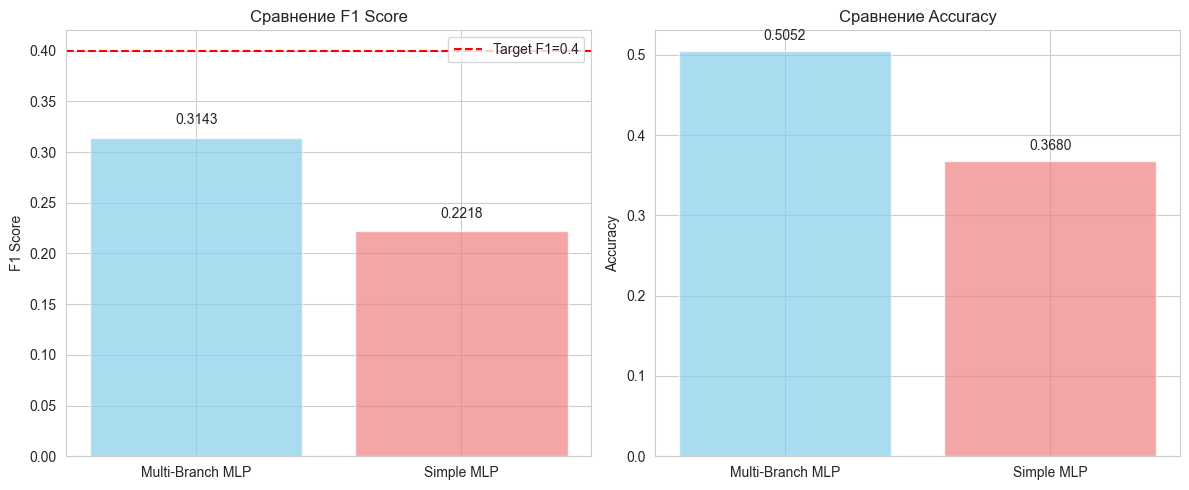

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Эксперимент с разными способами объединения:

Тестируем combine_mode: concat


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.1016, f1_macro=0.0646


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 28: accuracy=0.4341, f1_macro=0.2747


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: accuracy=0.4366, f1_macro=0.2760
  sum: F1=0.2760, Acc=0.4366


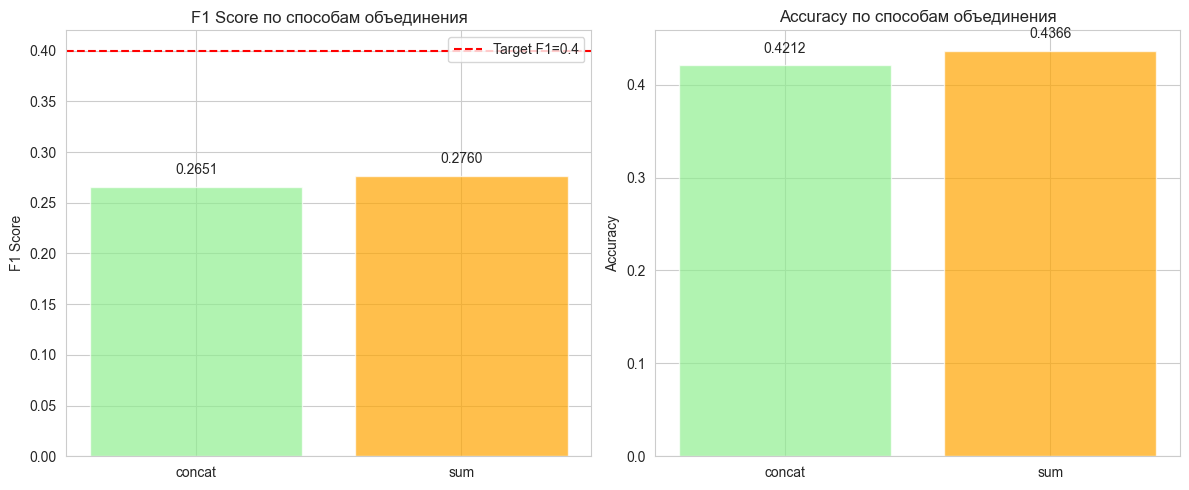

In [12]:


# ## 7. Анализ результатов

print("Архитектура итоговой модели:")
print(final_model)

# Сравнение с базовой моделью (один слой)
print("\n" + "="*50)
print("Сравнение с базовой моделью:")

# Простая базовая модель для сравнения
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.output_dim = output_dim  # Добавляем output_dim для совместимости
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Обучаем базовую модель
base_model = SimpleMLP(dm.input_dim, best_hidden_dim, dm.n_classes)
base_results = train_model(
    base_model,
    dm,
    class_weights=class_weights,
    max_epochs=50,
    lr=best_lr,
    optimizer_type=best_optimizer
)

print(f"Multi-Branch MLP - F1: {final_results['val_f1']:.4f}, Acc: {final_results['val_acc']:.4f}")
print(f"Simple MLP       - F1: {base_results['val_f1']:.4f}, Acc: {base_results['val_acc']:.4f}")

# Визуализация сравнения
models = ['Multi-Branch MLP', 'Simple MLP']
f1_scores = [final_results['val_f1'], base_results['val_f1']]
acc_scores = [final_results['val_acc'], base_results['val_acc']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# F1 сравнение
bars1 = ax1.bar(models, f1_scores, color=['skyblue', 'lightcoral'], alpha=0.7)
ax1.set_ylabel('F1 Score')
ax1.set_title('Сравнение F1 Score')
ax1.axhline(y=0.4, color='red', linestyle='--', label='Target F1=0.4')
ax1.legend()

# Accuracy сравнение
bars2 = ax2.bar(models, acc_scores, color=['skyblue', 'lightcoral'], alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Сравнение Accuracy')

# Добавим значения на столбцы
for bar, value in zip(bars1, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

for bar, value in zip(bars2, acc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Дополнительные эксперименты (опционально)

# %%
# Попробуем разные способы объединения веток
print("\n" + "="*50)
print("Эксперимент с разными способами объединения:")

combine_modes = ['concat', 'sum']
combine_results = {}

for mode in combine_modes:
    print(f"\nТестируем combine_mode: {mode}")

    model = MultiBranchMLP(
        input_dim=dm.input_dim,
        hidden_dim=best_hidden_dim,
        output_dim=dm.n_classes,
        num_blocks=best_depth,
        dropout=0.2,
        combine_mode=mode
    )

    results = train_model(
        model,
        dm,
        class_weights=class_weights,
        max_epochs=30,
        lr=best_lr,
        optimizer_type=best_optimizer
    )

    combine_results[mode] = results
    print(f"  {mode}: F1={results['val_f1']:.4f}, Acc={results['val_acc']:.4f}")

# Визуализация результатов разных способов объединения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

modes = list(combine_results.keys())
f1_combine = [combine_results[mode]['val_f1'] for mode in modes]
acc_combine = [combine_results[mode]['val_acc'] for mode in modes]

bars1 = ax1.bar(modes, f1_combine, color=['lightgreen', 'orange'], alpha=0.7)
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score по способам объединения')
ax1.axhline(y=0.4, color='red', linestyle='--', label='Target F1=0.4')
ax1.legend()

bars2 = ax2.bar(modes, acc_combine, color=['lightgreen', 'orange'], alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy по способам объединения')

for bar, value in zip(bars1, f1_combine):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

for bar, value in zip(bars2, acc_combine):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
 # ## 5. Улучшенное обучение с ранней остановкой
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint


def train_model_improved(
        model,
        dm,
        class_weights=None,
        max_epochs=100,
        lr=1e-3,
        optimizer_type='adamw',
        patience=15
):
    """
    Обучает модель с ранней остановкой и сохранением лучших весов.
    """
    # Loss function с весами классов
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )

    # Callbacks
    early_stop_callback = EarlyStopping(
        monitor='val_f1_macro',
        min_delta=0.001,
        patience=patience,
        verbose=True,
        mode='max'
    )

    checkpoint_callback = ModelCheckpoint(
        monitor='val_f1_macro',
        dirpath='./checkpoints/',
        filename='wine-quality-{epoch:02d}-{val_f1_macro:.3f}',
        save_top_k=1,
        mode='max'
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_checkpointing=True,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=True,
        deterministic=True
    )

    trainer.fit(lightning_model, dm)

    # Загружаем лучшую модель
    if checkpoint_callback.best_model_path:
        lightning_model = BaseLightningModule.load_from_checkpoint(
            checkpoint_callback.best_model_path,
            model=model,
            loss_fn=loss_fn,
            optimizer_type=optimizer_type,
            learning_rate=lr,
            task_type='multiclass'
        )

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item(),
        'best_model_path': checkpoint_callback.best_model_path if checkpoint_callback.best_model_path else None
    }


# ## 6. Быстрые эксперименты с меньшим числом эпох
def run_quick_experiments():
    """Быстрые эксперименты с ранней остановкой"""
    experiments = []

    # Ограниченный набор гиперпараметров для быстрого поиска
    configs = [
        {'hidden_dim': 256, 'depth': 4, 'lr': 5e-4, 'optimizer': 'adamw'},
        {'hidden_dim': 512, 'depth': 3, 'lr': 1e-3, 'optimizer': 'adamw'},
        {'hidden_dim': 128, 'depth': 6, 'lr': 5e-4, 'optimizer': 'adam'},
        {'hidden_dim': 512, 'depth': 4, 'lr': 1e-3, 'optimizer': 'adamw'},
    ]

    for i, config in enumerate(configs):
        print(f'\n=== Эксперимент {i + 1}/{len(configs)} ===')
        print(f"Config: {config}")

        model = MultiBranchMLP(
            input_dim=dm.input_dim,
            hidden_dim=config['hidden_dim'],
            output_dim=dm.n_classes,
            num_blocks=config['depth'],
            dropout=0.2,  # Немного увеличим dropout для регуляризации
            combine_mode='concat'
        )

        results = train_model_improved(
            model,
            dm,
            class_weights=class_weights,
            max_epochs=50,  # Уменьшим максимальное число эпох
            lr=config['lr'],
            optimizer_type=config['optimizer'],
            patience=10
        )

        experiment_result = config.copy()
        experiment_result.update(results)
        experiments.append(experiment_result)

        print(f"✓ F1: {results['val_f1']:.4f}, Acc: {results['val_acc']:.4f}")

    return pd.DataFrame(experiments)


# Запускаем быстрые эксперименты
print("Запуск быстрых экспериментов...")
results_df = run_quick_experiments()

# Находим лучший результат
best_result = results_df.loc[results_df['val_f1'].idxmax()]
print(f'\n=== Лучший результат ===')
print(best_result)

# Сохраняем результаты
results_df.to_csv('quick_experiment_results.csv', index=False)

# ## 7. Финальное обучение с лучшими параметрами
# Используем лучшие гиперпараметры из экспериментов
best_config = {
    'hidden_dim': int(best_result['hidden_dim']),
    'depth': int(best_result['depth']),
    'lr': best_result['lr'],
    'optimizer': best_result['optimizer']
}

print('Лучшие гиперпараметры:')
for key, value in best_config.items():
    print(f'  {key}: {value}')

# Обучаем финальную модель дольше
final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=best_config['hidden_dim'],
    output_dim=dm.n_classes,
    num_blocks=best_config['depth'],
    dropout=0.2,
    combine_mode='concat'
)

print(f"\nОбучаем финальную модель...")
final_results = train_model_improved(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=200,  # Больше эпох для финального обучения
    lr=best_config['lr'],
    optimizer_type=best_config['optimizer'],
    patience=20  # Больше терпения для ранней остановки
)

print(f'\n=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===')
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}")

if final_results['val_f1'] >= 0.4:
    print("🎉 Цель достигнута! F1 score ≥ 40%")
    if final_results['best_model_path']:
        print(f"Лучшая модель сохранена: {final_results['best_model_path']}")
else:
    print("❌ Цель не достигнута. Попробуйте следующие подходы:")
    print("   - Увеличьте размер модели (hidden_dim)")
    print("   - Попробуйте больше блоков (depth)")
    print("   - Поэкспериментируйте с разными learning rates")
    print("   - Добавьте больше данных или аугментаций")

# ## 8. Анализ результатов
# Визуализируем результаты экспериментов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=results_df, x='hidden_dim', y='val_f1', hue='depth', size='lr', sizes=(50, 200))
plt.title('F1 score vs Hidden Dimension')

plt.subplot(1, 3, 2)
sns.barplot(data=results_df, x='depth', y='val_f1', hue='optimizer')
plt.title('F1 score vs Depth')

plt.subplot(1, 3, 3)
sns.scatterplot(data=results_df, x='lr', y='val_f1', hue='optimizer', size='hidden_dim', sizes=(50, 200))
plt.xscale('log')
plt.title('F1 score vs Learning Rate')

plt.tight_layout()
plt.show()

# Выводим таблицу результатов
print("\nРезультаты всех экспериментов:")
print(results_df.round(4))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | MultiBranchMLP   | 3.5 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
2 | metrics | ModuleDict       | 0      | train
-----------------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
13.951    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode


Запуск быстрых экспериментов...

=== Эксперимент 1/4 ===
Config: {'hidden_dim': 256, 'depth': 4, 'lr': 0.0005, 'optimizer': 'adamw'}


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.1250, f1_macro=0.1133


Training: |          | 0/? [00:00<?, ?it/s]

...

Metric val_f1_macro improved by 0.001 >= min_delta = 0.001. New best score: 0.252


Epoch 34: accuracy=0.3958, f1_macro=0.2519


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_f1_macro improved by 0.002 >= min_delta = 0.001. New best score: 0.253


Epoch 35: accuracy=0.3982, f1_macro=0.2535
